# Mi Primer Perceptron - Pasos a Seguir

## 1. Cargar Datos

## 2. Sanity Check

## 3. Dividir (Compile)

## 4. Entrenar -> FIT

## 5. Predecir // Evaluar


==========================================================

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Cargar Datos

In [1]:
# Importar el Conjunto de Datos
from sklearn.datasets import fetch_openml

#Para que me lo devuelva como un Array
mnist = fetch_openml('mnist_784', as_frame=False)

In [2]:
dir(mnist)

['DESCR',
 'categories',
 'data',
 'details',
 'feature_names',
 'frame',
 'target',
 'target_names',
 'url']

In [3]:
mnist.DESCR

"**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  \n**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  \n**Please cite**:  \n\nThe MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  \n\nIt is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 

In [4]:
len(mnist.target)

70000

In [ ]:
mnist.data[0]

In [9]:
mnist.target[0]

'5'

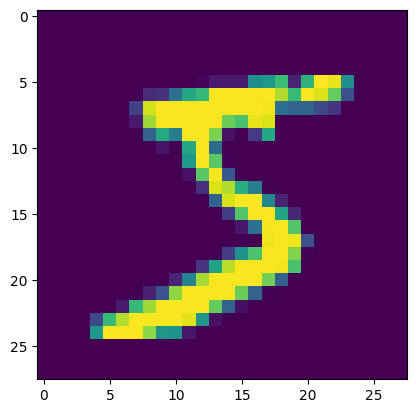

In [15]:
plt.imshow(mnist.data[0].reshape(28,28))
plt.show()

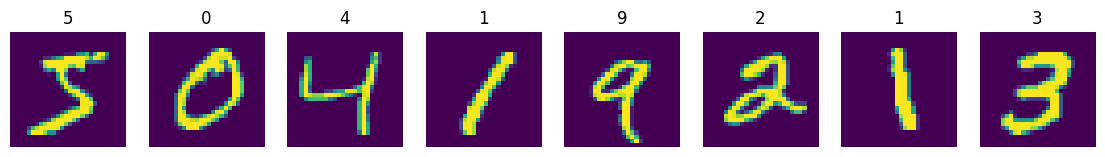

In [29]:
# Ejercicio dibuja las 8 primeras imagenes en una fila
plt.figure(figsize=(14,5))

for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(mnist.data[i].reshape(28,28))
    plt.title(mnist.target[i])
    plt.axis('off')

### Sanity Check

In [39]:
# ¿Está balanceado nuestros datos?
labels = mnist.target

unique, counts = np.unique(labels, return_counts=True)
dict(zip(unique, counts))

{'0': np.int64(6903),
 '1': np.int64(7877),
 '2': np.int64(6990),
 '3': np.int64(7141),
 '4': np.int64(6824),
 '5': np.int64(6313),
 '6': np.int64(6876),
 '7': np.int64(7293),
 '8': np.int64(6825),
 '9': np.int64(6958)}

In [40]:
df = pd.DataFrame(mnist.data)
df['target'] = mnist.target
df['target'].value_counts()

,count
target,
1,7877
7,7293
3,7141
2,6990
9,6958
0,6903
6,6876
8,6825
4,6824


### Dividir


In [46]:
#Dividir nuestro conjunto en train y en test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(mnist.data, mnist.target, test_size=10000)

In [49]:
print(f"Longitud de las variables de entrenamiento: {len(X_train)}")
print(f"Longitud de las variables de prueba: {len(X_test)}")


Longitud de las variables de entrenamiento: 60000
Longitud de las variables de prueba: 10000



### Entrenar -> FIT

In [48]:
from sklearn.linear_model import Perceptron

clf = Perceptron(max_iter=2000, random_state=42)
clf.fit(X_train, y_train)

Perceptron(max_iter=2000, random_state=42)

## Predecir // Evaluar

In [50]:
y_test[0]

'8'

In [51]:
clf.predict([X_test[0]])

array(['8'], dtype='<U1')

In [56]:
from sklearn.metrics import f1_score

f1_score(y_test, clf.predict(X_test), average="weighted")

0.8848811514779725

## MI SOLUCION

In [72]:
# Implementa el código en Python que consideres necesario para visualizar
# por pantalla algunas de las imagenes que han sido clasificadas
# de manera errónea por el algoritmo

# Predice todas las imágenes de test
predicciones = clf.predict(X_test)

# Encuentra los índices de las predicciones erróneas
imagenes_erroneas = [i for i, (pred, real) in enumerate(zip(predicciones, y_test)) if pred != real]

# Tomamos solo las primeras 8 imágenes erróneas
imagenes_erroneas = imagenes_erroneas[:8]


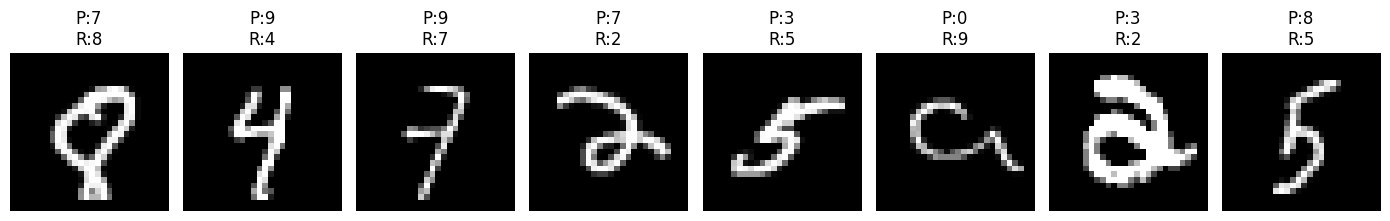

In [74]:
plt.figure(figsize=(14,5))

for i, idx in enumerate(imagenes_erroneas):
    plt.subplot(1, 8, i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"P:{predicciones[idx]}\nR:{y_test[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## SOLUCION CHELO

In [75]:
index = 0
index_errors = []

#Iteramos por el resultado de las etiquetas y lo que ha predecido
for etiqueta, predict in zip(y_test, clf.predict(X_test)):
    if etiqueta != predict:
        index_errors.append(index)
    index += 1

print(f"Errores: {len(index_errors)}")

index_errors = index_errors[:8]

Errores: 1149


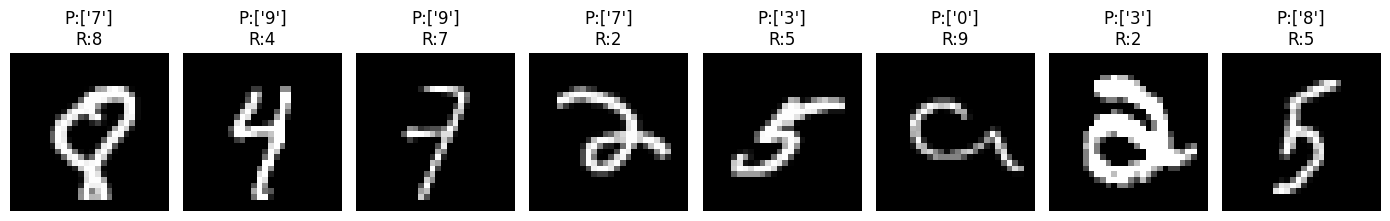

In [79]:
plt.figure(figsize=(14,5))

for index, img_index in zip(range(1,9), index_errors):
  plt.subplot(1, 8, index)
  plt.imshow(np.reshape(X_test[img_index], (28,28)), cmap='gray')
  plt.title(f"P:{clf.predict([X_test[img_index]])}\nR:{y_test[img_index]}")
  plt.axis('off')

plt.tight_layout()
plt.show()